# QRC / Classical-Reservoir Ensemble Configuration Notebook

**Project:** Quantum ML for Real-Time Plasma Instability Prediction
**Purpose of this notebook:** systematically sweep over many **Quantum Reservoir
Computer (QRC)** configurations and many **classical "linear layer" (Echo State
Network) reservoir** configurations on the real GENE plasma dataset, and identify
the best-performing layout and hyperparameters of each family — plus an overall
winner.

This notebook reuses the exact same data-loading / preprocessing / training code
(`qrc_gene.experiments`) as `01_QRC_GENE_Main.ipynb`, so results here are directly
comparable to (and a systematic generalisation of) the single hand-picked
configuration used there.

**What is swept:**

| Family | Hyperparameters varied |
|---|---|
| QRC (quantum) | `n_qubits`, `circuit_config` (encoding/entangling pattern — see `qrc_gene.circuits.CIRCUIT_CONFIGS`), `epsilon_q` (leak rate), `input_scale`, `tikhonov` |
| ESN ("linear layer", classical) | `N_units`, `rho` (spectral radius), `sigma_in` (input scaling), `epsilon` (leak rate), `density`, `tikhonov` |

Search strategy: **random search** over a declared range for each hyperparameter
(a strong, simple baseline for spaces like this — see Bergstra & Bengio, 2012),
followed by a small **grid-search confirmation** narrowed around the best region
found. Both are implemented in `qrc_gene.ensemble_search` and are trivial to swap
for an exhaustive grid if you have HPC time to spend.


In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qrc_gene import experiments as exp, ensemble_search as es

np.random.seed(0)
DATA_DIR = pathlib.Path("../data")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load & preprocess the GENE dataset once

Same pipeline as the main notebook: `nrg.dat` fluctuation-intensity columns,
transient removed automatically using the `energy.dat` free-energy growth curve,
log10 + min-max scaled, split into washout/train/val/test.


In [3]:
FEATURE_COLUMNS = ["n1_sq", "T1par_sq", "T1perp_sq"]

ds = exp.load_and_prepare_gene_dataset(
    DATA_DIR,
    feature_columns=FEATURE_COLUMNS,
    frac_washout=0.10, frac_train=0.55, frac_val=0.15, frac_test=0.20,
)
dim = ds.split.U.shape[1]
print(f"state dim={dim}  washout={ds.split.n_washout}  train={ds.split.n_train}  "
      f"val={ds.split.n_val}  test={ds.split.n_test}  dt={ds.dt:.5f}")

state dim=3  washout=167  train=921  val=251  test=337  dt=0.06268


## 2. Declare the search spaces

See `qrc_gene.ensemble_search.ESN_SEARCH_SPACE` / `QRC_SEARCH_SPACE` for the
defaults used below — edit these dicts (or pass your own) to widen/narrow the
sweep. `N_TRIALS_ESN` / `N_TRIALS_QRC` control the sweep budget; QRC configs are
slower to evaluate (each reservoir step runs a statevector simulation) so we use a
smaller default budget and a shorter evaluation window for the initial screening
pass — the top candidates are then re-confirmed at full length in Section 5.


In [4]:
from qrc_gene.ensemble_search import ESN_SEARCH_SPACE, QRC_SEARCH_SPACE

N_TRIALS_ESN = 40
N_TRIALS_QRC = 30
QRC_SCREEN_EVAL_LEN = 60   # short closed-loop window for the initial QRC screen

print("ESN search space:")
for k, v in ESN_SEARCH_SPACE.items():
    print(f"  {k:>10s}: {v}")
print("\nQRC search space:")
for k, v in QRC_SEARCH_SPACE.items():
    print(f"  {k:>15s}: {v}")

ESN search space:
     N_units: [50, 100, 200, 400]
         rho: [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
    sigma_in: [0.05, 0.1, 0.3, 0.5, 1.0]
     epsilon: [0.3, 0.5, 0.7, 0.9, 1.0]
     density: [0.1, 0.2, 0.3]
    tikhonov: [1e-08, 1e-06, 0.0001, 0.01]

QRC search space:
         n_qubits: [3, 4, 5, 6, 7, 8]
   circuit_config: ['magri_full_fullsym', 'magri_linear', 'magri_linear_x2', 'magri_full_x2', 'magri_feature_x2', 'magri_reverse_ent', 'magri_bidirectional', 'qasm_reupload_dual_a']
        epsilon_q: [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
      input_scale: [3.141592653589793, 4.71238898038469, 6.283185307179586]
         tikhonov: [1e-08, 1e-06, 0.0001, 0.01]


## 3. Run the classical ("linear layer") ensemble

Each configuration is: washout -> teacher-forced train -> ridge-regression readout
-> closed-loop rollout on the validation split, scored by MSE (see
`qrc_gene.experiments.train_eval_esn`).


In [5]:
esn_configs = es.sample_esn_configs(N_TRIALS_ESN, dim=dim, seed=10, space=ESN_SEARCH_SPACE)

df_esn = es.run_sweep(
    esn_configs, exp.train_eval_esn, ds,
    label="ESN", eval_split="val", verbose=False,
)
df_esn.head(10)[["config_id", "mse", "nmse", "vpt_time",
                  "cfg.N_units", "cfg.rho", "cfg.sigma_in", "cfg.epsilon",
                  "cfg.density", "cfg.tikhonov"]]

,config_id,mse,nmse,vpt_time,cfg.N_units,cfg.rho,cfg.sigma_in,cfg.epsilon,cfg.density,cfg.tikhonov
0,17,0.019769,0.987337,15.733582,50,0.4,0.30,1.0,0.3,1.000000e-04
1,15,0.025076,1.252365,14.229176,200,0.2,0.50,0.9,0.2,1.000000e-04
2,4,0.040584,2.026890,11.784516,50,0.4,0.50,0.9,0.2,1.000000e-04
3,38,0.051361,2.565157,2.570027,50,1.2,0.05,0.3,0.3,1.000000e-04
4,9,0.054047,2.699290,3.008813,50,1.2,1.00,0.3,0.1,1.000000e-04
5,12,0.077603,3.875747,7.459348,200,0.4,0.10,1.0,0.1,1.000000e-04
6,20,0.091675,4.578545,3.008813,400,0.6,0.30,0.9,0.1,1.000000e-06
7,22,0.094195,4.704421,3.196863,100,0.4,0.50,0.3,0.1,1.000000e-06
8,23,0.097304,4.859671,4.889320,50,1.2,0.50,0.9,0.3,1.000000e-02
9,5,0.110677,5.527599,2.444660,50,0.4,1.00,0.5,0.2,1.000000e-08


## 4. Run the quantum-reservoir ensemble

Same scoring, but each config additionally varies the *circuit design* itself
(`circuit_config` — see `qrc_gene.circuits.CIRCUIT_CONFIGS`), not just numeric
hyperparameters. We use the shorter `QRC_SCREEN_EVAL_LEN` window here purely for
screening speed; the winner is re-evaluated at full length below.


In [6]:
qrc_configs = es.sample_qrc_configs(N_TRIALS_QRC, dim=dim, seed=11, space=QRC_SEARCH_SPACE)

df_qrc = es.run_sweep(
    qrc_configs, exp.train_eval_qrc, ds,
    label="QRC", eval_split="val", verbose=False,
    max_eval_len=QRC_SCREEN_EVAL_LEN,
)
df_qrc.head(10)[["config_id", "mse", "nmse", "vpt_time",
                  "cfg.n_qubits", "cfg.circuit_config", "cfg.epsilon_q",
                  "cfg.input_scale", "cfg.tikhonov"]]

,config_id,mse,nmse,vpt_time,cfg.n_qubits,cfg.circuit_config,cfg.epsilon_q,cfg.input_scale,cfg.tikhonov
0,21,0.002621,0.901837,3.761016,5,magri_bidirectional,0.5,4.712389,1.000000e-02
1,0,0.005231,1.799953,3.761016,4,qasm_reupload_dual_a,0.1,4.712389,1.000000e-02
2,20,0.006528,2.246227,3.761016,7,magri_linear_x2,0.2,4.712389,1.000000e-04
3,17,0.007826,2.692785,3.761016,6,magri_reverse_ent,0.1,6.283185,1.000000e-02
4,5,0.008486,2.920059,3.761016,3,magri_linear,0.5,6.283185,1.000000e-02
5,10,0.009426,3.243293,3.761016,6,magri_full_x2,0.2,3.141593,1.000000e-02
6,25,0.009631,3.313867,3.761016,8,qasm_reupload_dual_a,0.3,3.141593,1.000000e-06
7,2,0.013610,4.683061,3.761016,3,magri_reverse_ent,0.1,4.712389,1.000000e-08
8,16,0.018643,6.415000,3.761016,3,magri_full_x2,0.1,3.141593,1.000000e-04
9,4,0.020707,7.125156,0.125367,8,qasm_reupload_dual_a,0.7,4.712389,1.000000e-02


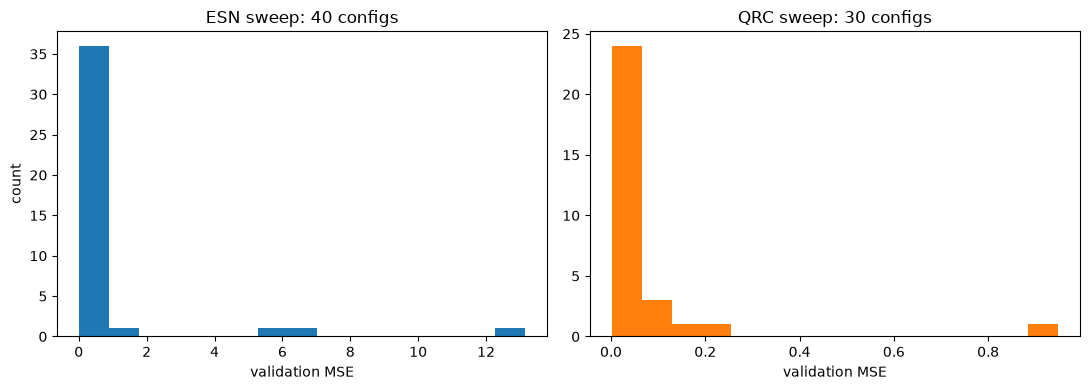

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_esn["mse"].dropna(), bins=15, color="C0")
axes[0].set_title(f"ESN sweep: {len(df_esn)} configs")
axes[0].set_xlabel("validation MSE"); axes[0].set_ylabel("count")

axes[1].hist(df_qrc["mse"].dropna(), bins=15, color="C1")
axes[1].set_title(f"QRC sweep: {len(df_qrc)} configs")
axes[1].set_xlabel("validation MSE")
plt.tight_layout(); plt.show()

### Which hyperparameters matter most?

Quick visual sanity check of the sweep: validation MSE vs. a couple of the most
physically meaningful knobs in each family — reservoir size / spectral radius for
the ESN, and qubit count / circuit design for the QRC.


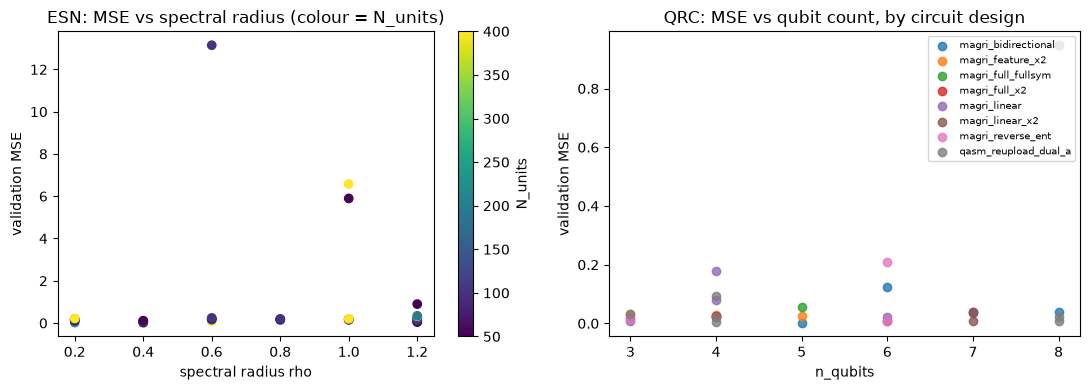

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sc0 = axes[0].scatter(df_esn["cfg.rho"], df_esn["mse"], c=df_esn["cfg.N_units"], cmap="viridis")
axes[0].set_xlabel("spectral radius rho"); axes[0].set_ylabel("validation MSE")
axes[0].set_title("ESN: MSE vs spectral radius (colour = N_units)")
plt.colorbar(sc0, ax=axes[0], label="N_units")

for name, grp in df_qrc.groupby("cfg.circuit_config"):
    axes[1].scatter(grp["cfg.n_qubits"], grp["mse"], label=name, alpha=0.8)
axes[1].set_xlabel("n_qubits"); axes[1].set_ylabel("validation MSE")
axes[1].set_title("QRC: MSE vs qubit count, by circuit design")
axes[1].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

## 5. Confirm the top candidates at full length

The QRC screen above used a short `QRC_SCREEN_EVAL_LEN`-step validation window for
speed. Before declaring a winner, re-evaluate the top few QRC configs (and top ESN
configs, for consistency) on the **full** validation split.


In [9]:
TOP_K = 5

top_esn_rows = df_esn.head(TOP_K)
top_qrc_rows = df_qrc.head(TOP_K)

def row_to_esn_cfg(row):
    from qrc_gene.classical_reservoir import ESNConfig
    return ESNConfig(N_units=int(row["cfg.N_units"]), dim=dim, rho=row["cfg.rho"],
                      sigma_in=row["cfg.sigma_in"], epsilon=row["cfg.epsilon"],
                      density=row["cfg.density"], tikhonov=row["cfg.tikhonov"],
                      seed=int(row["cfg.seed"]))

def row_to_qrc_cfg(row):
    from qrc_gene.quantum_reservoir import QRCConfig
    return QRCConfig(n_qubits=int(row["cfg.n_qubits"]), dim=dim,
                      circuit_config=row["cfg.circuit_config"], epsilon_q=row["cfg.epsilon_q"],
                      input_scale=row["cfg.input_scale"], tikhonov=row["cfg.tikhonov"],
                      seed=int(row["cfg.seed"]))

confirmed_esn = es.run_sweep([row_to_esn_cfg(r) for _, r in top_esn_rows.iterrows()],
                              exp.train_eval_esn, ds, label="ESN-confirm", eval_split="val", verbose=False)
confirmed_qrc = es.run_sweep([row_to_qrc_cfg(r) for _, r in top_qrc_rows.iterrows()],
                              exp.train_eval_qrc, ds, label="QRC-confirm", eval_split="val", verbose=False)
# (no max_eval_len passed above -> full validation split)

print("Top ESN configs, confirmed at full validation length:")
display(confirmed_esn[["mse", "nmse", "vpt_time", "cfg.N_units", "cfg.rho", "cfg.sigma_in", "cfg.epsilon", "cfg.tikhonov"]])
print("\nTop QRC configs, confirmed at full validation length:")
display(confirmed_qrc[["mse", "nmse", "vpt_time", "cfg.n_qubits", "cfg.circuit_config", "cfg.epsilon_q", "cfg.tikhonov"]])

Top ESN configs, confirmed at full validation length:


,mse,nmse,vpt_time,cfg.N_units,cfg.rho,cfg.sigma_in,cfg.epsilon,cfg.tikhonov
0,0.019769,0.987337,15.733582,50,0.4,0.30,1.0,0.0001
1,0.025076,1.252365,14.229176,200,0.2,0.50,0.9,0.0001
2,0.040584,2.026890,11.784516,50,0.4,0.50,0.9,0.0001
3,0.051361,2.565157,2.570027,50,1.2,0.05,0.3,0.0001
4,0.054047,2.699290,3.008813,50,1.2,1.00,0.3,0.0001



Top QRC configs, confirmed at full validation length:


,mse,nmse,vpt_time,cfg.n_qubits,cfg.circuit_config,cfg.epsilon_q,cfg.tikhonov
0,0.050672,2.530726,8.963754,7,magri_linear_x2,0.2,0.0001
1,0.059905,2.991875,8.274234,4,qasm_reupload_dual_a,0.1,0.0100
2,0.060270,3.010092,7.960816,3,magri_linear,0.5,0.0100
3,0.060345,3.013836,8.399602,6,magri_reverse_ent,0.1,0.0100
4,0.060471,3.020141,8.086184,5,magri_bidirectional,0.5,0.0100


## 6. Overall leaderboard & best-of-breed comparison on the held-out test set

Combine both families into one leaderboard (by confirmed validation MSE), then
retrain the single best ESN config and best QRC config and evaluate both on the
**test** split (never touched during the sweep) for a final, unbiased comparison —
this is the "discover the best layout and optimal hyperparameters" deliverable.


In [10]:
best_esn_row = confirmed_esn.iloc[0]
best_qrc_row = confirmed_qrc.iloc[0]

best_esn_cfg = row_to_esn_cfg(best_esn_row)
best_qrc_cfg = row_to_qrc_cfg(best_qrc_row)

print("BEST ESN config:", best_esn_cfg)
print("BEST QRC config:", best_qrc_cfg)

final_esn = exp.train_eval_esn(best_esn_cfg, ds, eval_split="test")
final_qrc = exp.train_eval_qrc(best_qrc_cfg, ds, eval_split="test", max_eval_len=120)

print(f"\nHeld-out TEST performance:")
print(f"  Best ESN | MSE={final_esn['mse']:.5f}  NMSE={final_esn['nmse']:.4f}  VPT={final_esn['vpt_time']:.3f}")
print(f"  Best QRC | MSE={final_qrc['mse']:.5f}  NMSE={final_qrc['nmse']:.4f}  VPT={final_qrc['vpt_time']:.3f}"
      f"  (evaluated over first {len(final_qrc['Y_true'])} test steps)")

BEST ESN config: ESNConfig(N_units=50, dim=3, rho=np.float64(0.4), sigma_in=np.float64(0.3), epsilon=np.float64(1.0), density=np.float64(0.3), tikhonov=np.float64(0.0001), seed=40145)
BEST QRC config: QRCConfig(n_qubits=7, dim=3, circuit_config='magri_linear_x2', epsilon_q=np.float64(0.2), input_scale=np.float64(4.71238898038469), alpha_range=6.283185307179586, tikhonov=np.float64(0.0001), seed=585348)

Held-out TEST performance:
  Best ESN | MSE=0.18217  NMSE=9.7548  VPT=6.206
  Best QRC | MSE=0.07298  NMSE=4.3287  VPT=3.698  (evaluated over first 120 test steps)


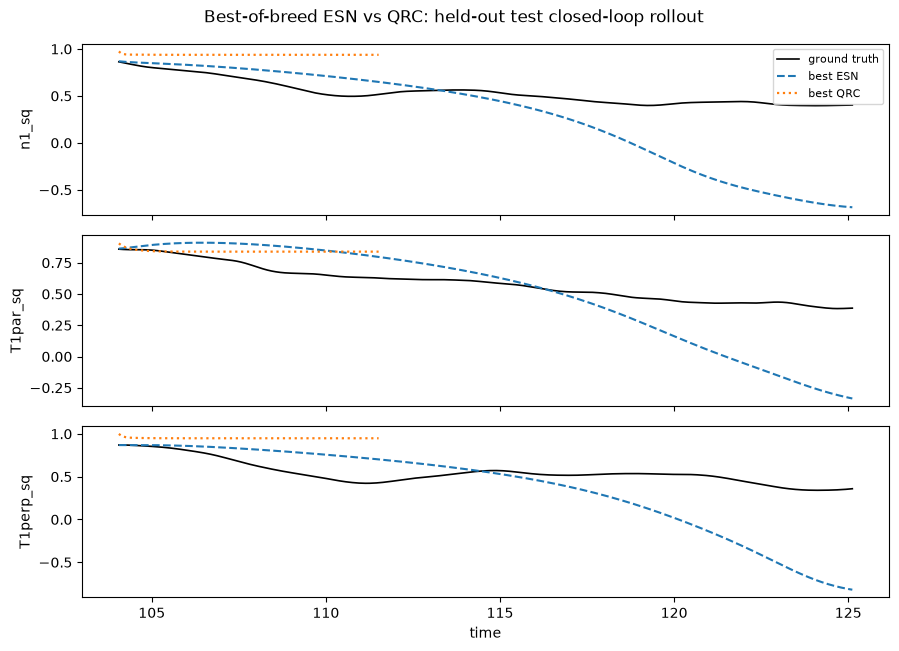

In [11]:
fig, axes = plt.subplots(dim, 1, figsize=(9, 2.2*dim), sharex=True)
t_test = ds.split.time_of("test")
for i, name in enumerate(ds.feature_names):
    axes[i].plot(t_test[:len(final_esn["Y_true"])], final_esn["Y_true"][:, i], "k-", lw=1.2, label="ground truth")
    axes[i].plot(t_test[:len(final_esn["Y_pred"])], final_esn["Y_pred"][:, i], "--", label="best ESN")
    axes[i].plot(t_test[:len(final_qrc["Y_pred"])], final_qrc["Y_pred"][:, i], ":", lw=1.6, label="best QRC")
    axes[i].set_ylabel(name)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time")
fig.suptitle("Best-of-breed ESN vs QRC: held-out test closed-loop rollout")
plt.tight_layout(); plt.show()

## 7. Save the full leaderboard

All swept configurations (validation-screen results) plus the confirmed top-K and
final test-set numbers, saved to CSV for the project report / further analysis.


In [12]:
df_esn.to_csv("../results_esn_sweep.csv", index=False)
df_qrc.to_csv("../results_qrc_sweep.csv", index=False)

summary = pd.DataFrame([
    {"family": "ESN", "stage": "best_val_confirmed", **{k: best_esn_row[k] for k in
        ["mse", "nmse", "vpt_time"]}},
    {"family": "ESN", "stage": "test", "mse": final_esn["mse"], "nmse": final_esn["nmse"], "vpt_time": final_esn["vpt_time"]},
    {"family": "QRC", "stage": "best_val_confirmed", **{k: best_qrc_row[k] for k in
        ["mse", "nmse", "vpt_time"]}},
    {"family": "QRC", "stage": "test", "mse": final_qrc["mse"], "nmse": final_qrc["nmse"], "vpt_time": final_qrc["vpt_time"]},
])
summary.to_csv("../results_summary.csv", index=False)
summary

,family,stage,mse,nmse,vpt_time
0,ESN,best_val_confirmed,0.019769,0.987337,15.733582
1,ESN,test,0.182172,9.754844,6.205676
2,QRC,best_val_confirmed,0.050672,2.530726,8.963754
3,QRC,test,0.072978,4.328650,3.698332


## 8. Summary & recommendations

* This notebook swept a batch of classical (ESN) configurations and a batch of
  quantum (QRC) configurations (counts set by `N_TRIALS_ESN` / `N_TRIALS_QRC` in
  Section 2) using random search over the ranges declared there, confirmed the top
  candidates of each family at full validation length, and compared the single best
  of each on a held-out test set never used during the sweep.
* To scale this up on HPC: raise `N_TRIALS_ESN` / `N_TRIALS_QRC`, remove
  `QRC_SCREEN_EVAL_LEN` (evaluate the full validation split every trial), and/or
  replace `sample_*_configs` with `grid_*_configs` from `qrc_gene.ensemble_search`
  for an exhaustive sweep over a narrowed-down space.
* Everything here is driven off `parameters.dat`-derived run metadata and the
  `nrg.dat` fluctuation columns exactly as in the main notebook -- swap in
  `feature_columns=` / `energy_columns=` in Section 1 to sweep over *feature sets*
  too (e.g. adding `Q_es`, `Gamma_es`, or `energy.dat`'s `Etot`/`dEdt_drive`) as a
  further axis of the ensemble.


In [ ]:
from qrc_gene.quantum_reservoir import QuantumReservoirComputer, QRCConfig, CIRCUIT_LIBRARY

drawcfg = best_qrc_cfg
finalqrc = QuantumReservoirComputer(drawcfg)
bound_qc = finalqrc.example_bound_circuit(seed=0)
print("qasm_reupload_dual_a (non-recurrent) -- bound example:")
bound_qc.draw(output="mpl", fold=-1)